# 1. Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

df = pd.read_csv('messy_ecommerce_sales_data.csv')
print("-----------------------Data Set-----------------------------")
display(df.head(20))


-----------------------Data Set-----------------------------


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled,366.180
6,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
7,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,PayPal,Returned,2938.400
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,Cash on Delivery,Processing,600.290
9,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.700


# 2. Total Row and Column

In [2]:
print("Total Row: ",{df.shape[0]})
print("Total Column: ",{df.shape[1]})

Total Row:  {103}
Total Column:  {11}


# 3. Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [4]:
df.describe()

,ID,Total
count,103.000000,89.000000
mean,149.640777,1232.949101
std,28.704326,2605.471455
min,100.000000,-20000.000000
25%,125.500000,582.130000
50%,149.000000,1138.760000
75%,174.500000,2153.400000
max,199.000000,4722.700000


# 4. Find Missing Value


In [5]:
df_missing = df.isnull().sum()[df.isnull().sum() > 0] # Just only show the missing value by Column
print("-----------------------Missing Value-----------------------------")
display(df_missing)

-----------------------Missing Value-----------------------------


,0
Category,8
Quantity,5
Price,5
Total,14


# 5. Duplicate value

In [6]:
df_clean = df.copy()
print("-----------------------Duplicate Value-----------------------------")
display(df_clean.duplicated().sum())

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print("Before: ",before)
print("After: ",after)
print(f"Sum: {before - after} ")

-----------------------Duplicate Value-----------------------------


np.int64(1)

Before:  103
After:  102
Sum: 1 


# 6. Text Columns case + whitespace standardize

In [7]:
# 6. Text Columns case + whitespace standardize
text_col_titles = [' Customer_Name', 'Product', ' Category']

# .str.strip() -> leading/trailing space remove
# .str.title() -> "Each Word Capitalized" format (consistent case)
for col in text_col_titles:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Payment method 'cash' replace by 'cash on delivery'
df_clean["Payment_Method"] = (
    df_clean["Payment_Method"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("cash on delivery","cash")
)

# Quantity 'NaN' replace by 1
df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors='coerce')
df_clean["Quantity"] = df_clean["Quantity"].fillna(1)
df_clean["Quantity"] = df_clean["Quantity"].astype(int)

# Total column cleaning
df_clean["Total"] = pd.to_numeric(df_clean["Total"], errors='coerce')
total_mean = df_clean["Total"].mean()
print("Mean", total_mean)
df_clean["Total"] = df_clean["Total"].fillna(total_mean)
df_clean["Total"] = df_clean["Total"].astype(int)

# 'nan' string replace
df_clean = df_clean.replace({
    "nan": np.nan,
    "NaN": np.nan,
    "Nan": np.nan
})

print("\n")
print(f"Final Dataset Shape: {df_clean.shape}")
print("-----------------------Text Columns case + whitespace standardize-----------------------------")
display(df_clean.head(20))

Mean 1230.927613636364


Final Dataset Shape: (102, 11)
-----------------------Text Columns case + whitespace standardize-----------------------------


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,cash,Shipped,114
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,paypal,Processing,1230
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,paypal,Delivered,389
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,paypal,Processing,1169
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,cash,Processing,552
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,cash,Cancelled,366
6,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,1,978.63,bank transfer,Processing,1230
7,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,paypal,Returned,2938
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,cash,Processing,600
9,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,credit card,Shipped,841


 # 7. Remove all  Unknown data


In [8]:
# 7. Remove rows with actual 'Unknown' strings

# First, clean the 'Price' column for non-numeric values
def clean_price_local(Value):
  if pd.isna(Value):
    return np.nan
  value_str = str(Value).strip()
  # Remove common currency symbols, commas, and any non-numeric characters except for the decimal point
  value_str = value_str.replace('$', '').replace('€', '').replace('£', '').replace(',', '').replace(' ', '')
  try:
    return float(value_str)
  except ValueError:
    return np.nan

df_clean["Price"] = df_clean["Price"].apply(clean_price_local)
df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors='coerce') # Ensure it's numeric, converting any lingering issues

# Now, remove rows with any NaN values, including those newly created in 'Price'
df_clean = df_clean.dropna()

# Define a function to identify 'Unknown' or other placeholder strings
def is_unknown(val):
    return str(val).strip().lower() == 'unknown'

# Filter out rows where any column contains the string 'Unknown'
mask = df_clean.apply(lambda row: row.astype(str).str.contains('unknown', case=False, na=False).any(), axis=1)
df_clean = df_clean[~mask]

# Define the final dataset variable and reset index
df_final_clean = df_clean.copy().reset_index(drop=True)

print(f"Rows remaining after removing all NaN and 'Unknown' values: {len(df_final_clean)}")
print('\n')
print("-----------------------Fully Cleaned Dataset Created-----------------------------")
print(f"Final Dataset Shape: {df_final_clean.shape}")
print('\n')
display(df_final_clean.head(20))

Rows remaining after removing all NaN and 'Unknown' values: 86


-----------------------Fully Cleaned Dataset Created-----------------------------
Final Dataset Shape: (86, 11)




,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38.00,cash,Shipped,114
1,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,paypal,Delivered,389
2,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,paypal,Processing,1169
3,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,cash,Processing,552
4,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,cash,Cancelled,366
5,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,1,978.63,bank transfer,Processing,1230
6,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,paypal,Returned,2938
7,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,cash,Processing,600
8,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,credit card,Shipped,841
9,111,Customer_111,ORD-72349,10/22/2025,Comics,Books,2,865.77,credit card,Returned,1731


# 8. Find Unique Product and Catagory

In [9]:
# Calculate unique product names, unique categories, and their mapping
unique_names = sorted(df_final_clean['Product'].unique())
unique_categories = sorted(df_final_clean[' Category'].unique())
unique_pairs = df_final_clean[['Product', ' Category']].drop_duplicates().sort_values(by=[' Category', 'Product'])

print(f"--- Dataset Summary ---")
print(f"Total Unique Products: {len(unique_names)}")
print(f"Total Unique Categories: {len(unique_categories)}")
print(f"Total Unique Product-Category Combinations: {len(unique_pairs)}")

print('\nUnique Product List:')
print(unique_names)

print('\nUnique Category List:')
print(unique_categories)

print('\nDetailed mapping of Products to their Categories:')
display(unique_pairs.reset_index(drop=True))

--- Dataset Summary ---
Total Unique Products: 20
Total Unique Categories: 6
Total Unique Product-Category Combinations: 27

Unique Product List:
['Basketball', 'Biography', 'Blender', 'Comics', 'Fiction', 'Football', 'Headphones', 'Jacket', 'Jeans', 'Lamp', 'Laptop', 'Microwave', 'Science', 'Shoes', 'Smartphone', 'Smartwatch', 'T-Shirt', 'Tennis Racket', 'Vacuum', 'Yoga Mat']

Unique Category List:
['Books', 'Clothing', 'Electronic', 'Electronics', 'Home', 'Sports']

Detailed mapping of Products to their Categories:


,Product,Category
0,Biography,Books
1,Comics,Books
2,Fiction,Books
3,Science,Books
4,Jacket,Clothing
5,Jeans,Clothing
6,Shoes,Clothing
7,T-Shirt,Clothing
8,Basketball,Electronic
9,Blender,Electronic


--- Dataset Summary ---
Total Unique Products: 20
Total Unique Categories: 6
Total Unique Product-Category Combinations: 27

# 9. Best selling Product with Quantity

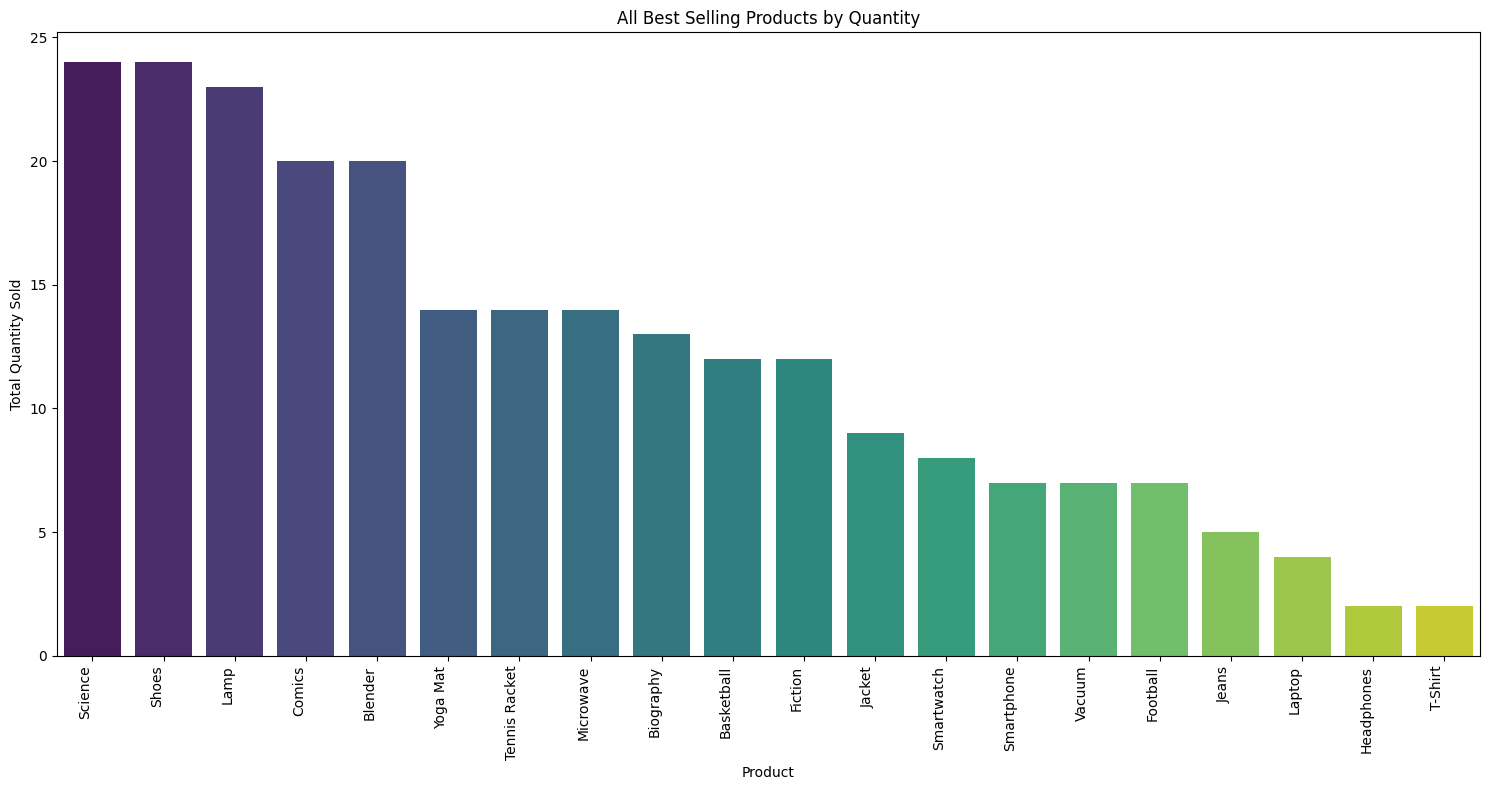

In [10]:
# Best selling Product with Quantity

# Group by Product and sum the Quantity
best_selling_products = df_final_clean.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

# Create a bar plot for all products
plt.figure(figsize=(15, 8)) # Increased figure size to accommodate more bars
sn.barplot(x=best_selling_products.index, y=best_selling_products.values, palette='viridis', hue=best_selling_products.index, legend=False)
plt.title('All Best Selling Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90, ha='right') # Rotate product names for better readability, and increased rotation angle
plt.tight_layout()
plt.show()

# 10. Category wise Payment method

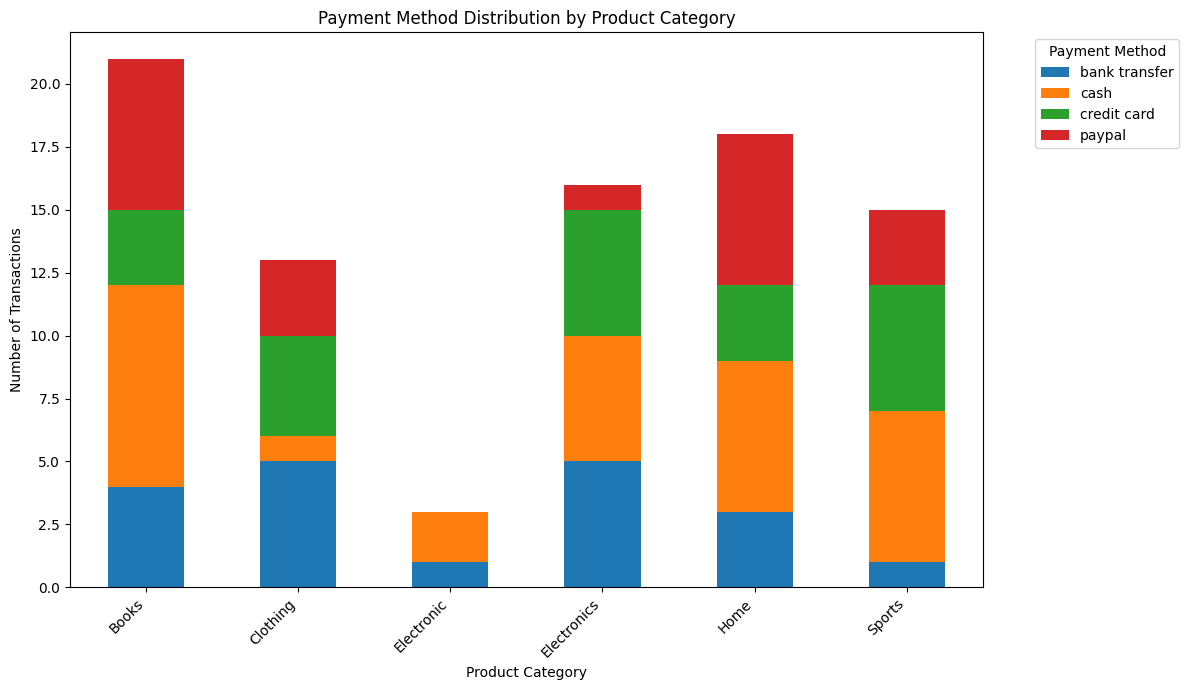

In [11]:
# Category wise Payment method

# Group by 'Category' and 'Payment_Method' and count occurrences
payment_method_by_category = df_final_clean.groupby([' Category', 'Payment_Method']).size().unstack(fill_value=0)

# Create a stacked bar plot
payment_method_by_category.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Payment Method Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Total Revenue by Payment Method

In [12]:
# Total Revenue
total_revenue = df_final_clean['Total'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $107,367.00


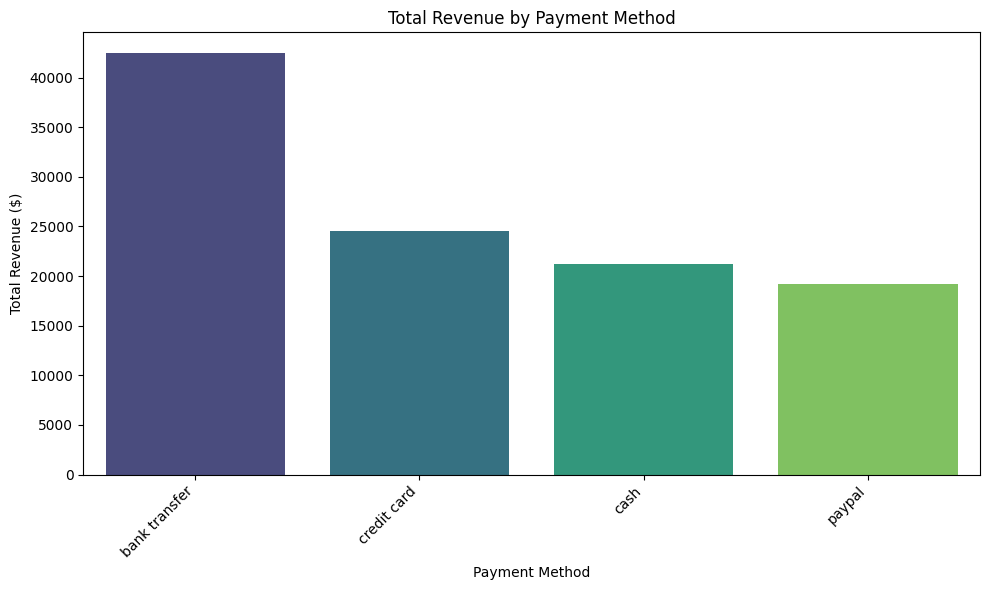

In [13]:
revenue_by_payment_method = df_final_clean.groupby('Payment_Method')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sn.barplot(x=revenue_by_payment_method.index, y=revenue_by_payment_method.values, palette='viridis', hue=revenue_by_payment_method.index, legend=False)
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Total Revenue by Product Category

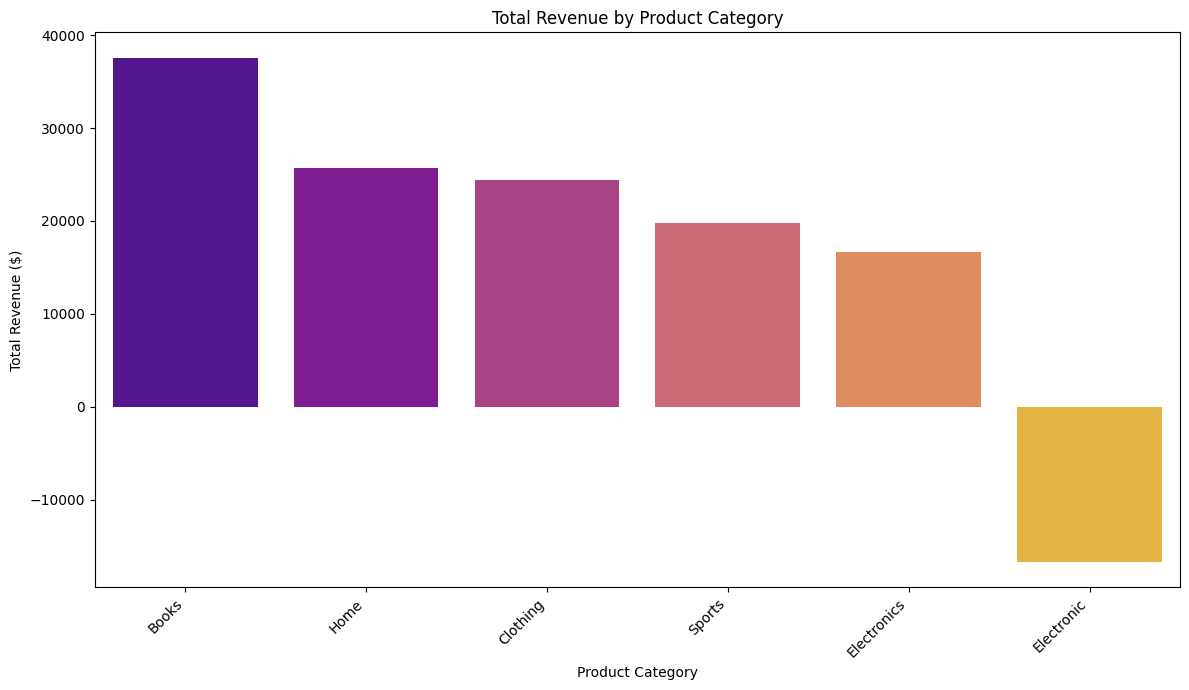

In [14]:
revenue_by_category = df_final_clean.groupby(' Category')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sn.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='plasma', hue=revenue_by_category.index, legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 13. Order Status

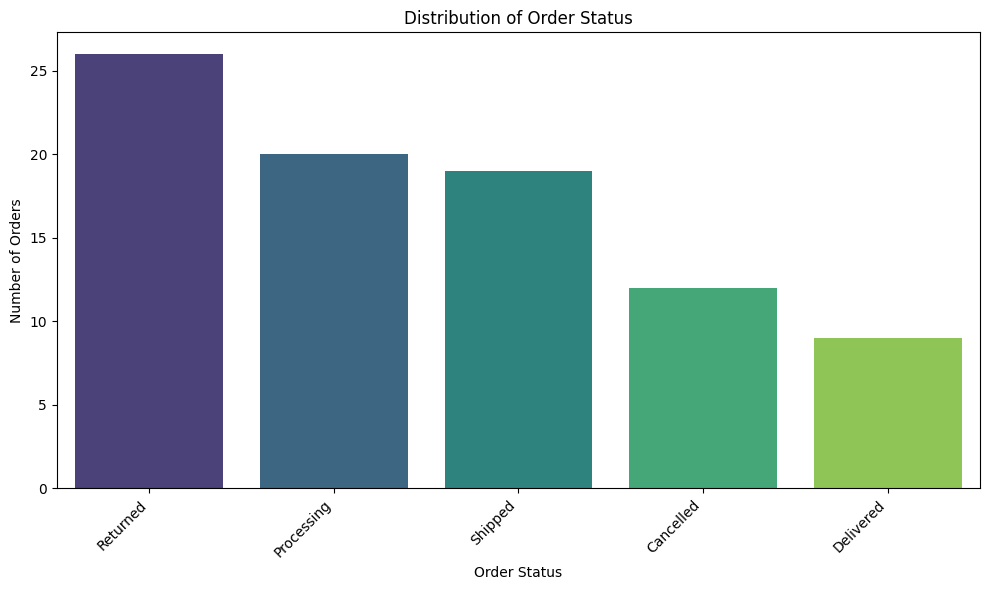

In [15]:
status_counts = df_final_clean['Status'].value_counts()

plt.figure(figsize=(10, 6))
sn.barplot(x=status_counts.index, y=status_counts.values, palette='viridis', hue=status_counts.index, legend=False)
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#14. Product Distribution by Catagory Heatmap

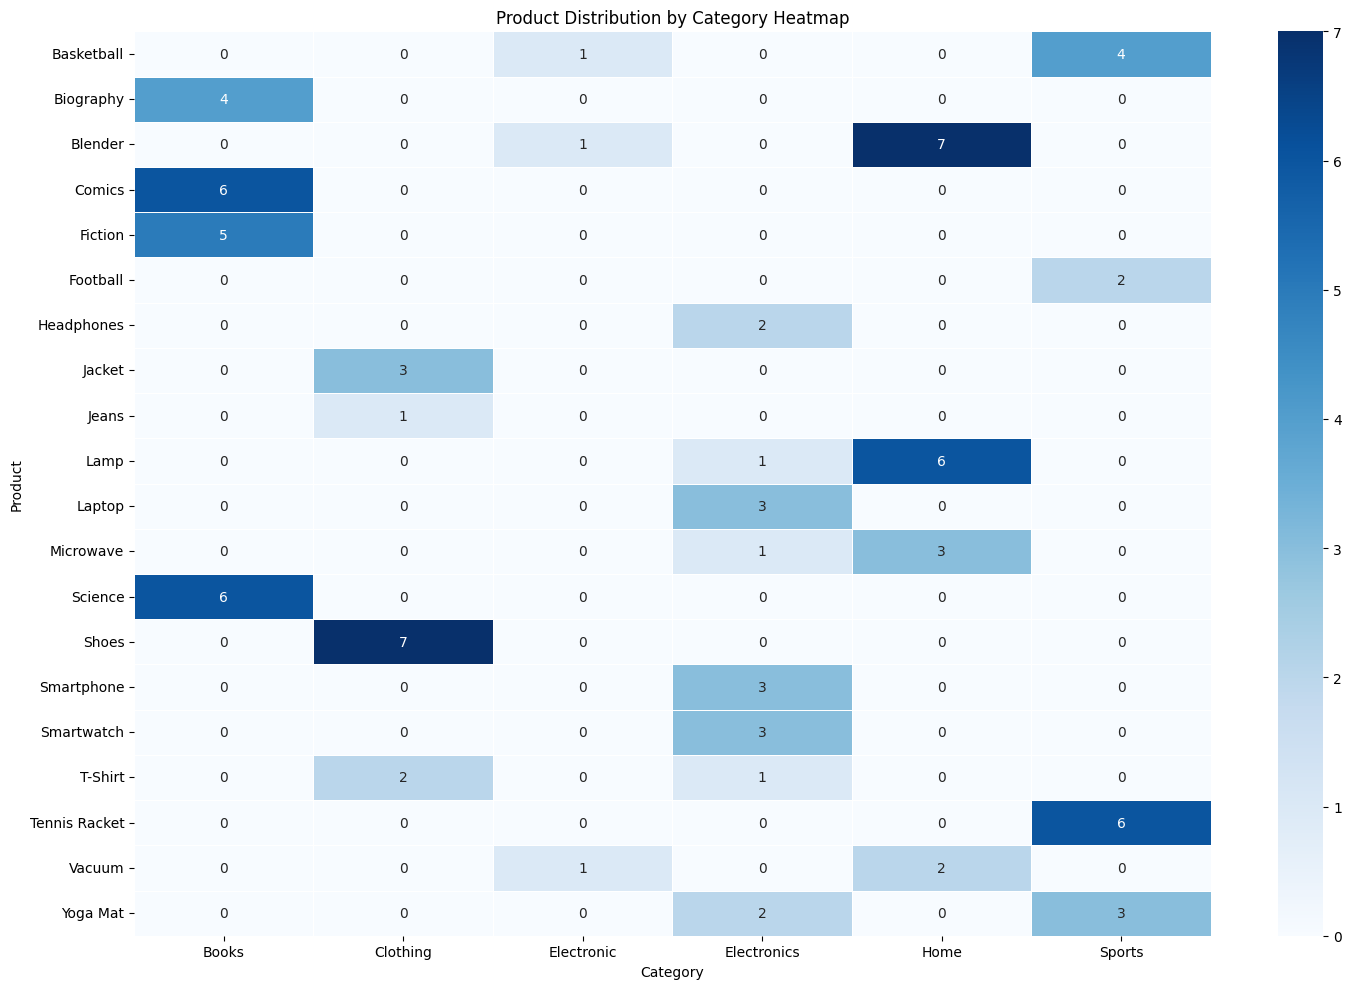

In [16]:
import seaborn as sn
import matplotlib.pyplot as plt

# Create a contingency table (cross-tabulation) of Product and Category
product_category_counts = pd.crosstab(df_final_clean['Product'], df_final_clean[' Category'])

# Create a heatmap
plt.figure(figsize=(15, 10))
sn.heatmap(product_category_counts, annot=True, cmap='Blues', fmt='d', linewidths=.5)
plt.title('Product Distribution by Category Heatmap')
plt.xlabel('Category')
plt.ylabel('Product')
plt.tight_layout()
plt.show()